In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import pickle
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Cargar datos
daily = pd.read_csv("../data/processed/eurusd_con_sentimiento.csv",
                    index_col=0, parse_dates=True)

# Cargar HMM
with open("../data/processed/hmm_model.pkl", "rb") as f:
    hmm_model = pickle.load(f)
with open("../data/processed/hmm_scaler.pkl", "rb") as f:
    hmm_scaler = pickle.load(f)

# Nuevo target — dirección a 20 días
daily['target_20d'] = (daily['Close'].shift(-20) > daily['Close']).astype(int)

features_v2 = [
    'trend_20_50', 'trend_50_200', 'momentum_20',
    'momentum_10', 'momentum_5', 'volatility_20',
    'volatility_60', 'regime', 'atr_14', 'rsi_14',
    'macd', 'macd_hist', 'bb_width', 'bb_position',
    'sentiment_score', 'return_lag_1', 'return_lag_2', 'return_lag_3'
]

thresholds = {0: None, 1: 0.65, 2: 0.60}

data = daily[features_v2 + ['target_20d', 'returns', 'regime']].dropna()
data = data.loc[:, ~data.columns.duplicated()]

print(f"Dataset: {data.shape}")
print(f"Período: {data.index[0].date()} → {data.index[-1].date()}")
print("Listo para walk-forward v2.0")

Dataset: (4031, 20)
Período: 2010-10-08 → 2026-04-03
Listo para walk-forward v2.0


In [2]:
# Walk-forward validation KRONOS v2.0
window_train = 756   # 3 años
window_test = 63     # 3 meses
resultados_wf = []

n_splits = (len(data) - window_train) // window_test
print(f"Total splits: {n_splits}")
print(f"Ejecutando walk-forward v2.0...")

for i in range(n_splits):
    start_train = i * window_test
    end_train = start_train + window_train
    end_test = end_train + window_test

    if end_test > len(data):
        break

    # Datos
    train_data = data.iloc[start_train:end_train]
    test_data = data.iloc[end_train:end_test]

    X_tr = train_data[features_v2].values
    y_tr = train_data['target_20d'].values
    X_te = test_data[features_v2].values
    y_te = test_data['target_20d'].values

    # Entrenar Fusion Layer v2
    modelo = xgb.XGBClassifier(
        n_estimators=300, max_depth=4,
        learning_rate=0.03, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5,
        random_state=42, verbosity=0
    )
    modelo.fit(X_tr, y_tr)

    # Generar señales con threshold dinámico por régimen
    confianzas = modelo.predict_proba(X_te)[:, 1]
    regimenes = test_data['regime'].values.flatten()
    rets = test_data['returns'].values

    posiciones = np.zeros(len(rets))
    for reg in [0, 1, 2]:
        mask = (regimenes == reg)
        threshold = thresholds.get(reg, None)
        if threshold is None:
            continue
        posiciones[mask] = np.where(
            confianzas[mask] > threshold, 1,
            np.where(confianzas[mask] < (1 - threshold), -1, 0)
        )

    # Métricas
    strat_rets = posiciones * rets
    sharpe = strat_rets.mean() / strat_rets.std() * np.sqrt(252) if strat_rets.std() > 0 else 0
    acc = accuracy_score(y_te, modelo.predict(X_te))
    dias_activo = (posiciones != 0).sum()

    resultados_wf.append({
        'periodo': i + 1,
        'fecha': data.index[end_train].date(),
        'sharpe': round(sharpe, 3),
        'accuracy': round(acc, 3),
        'dias_activo': int(dias_activo),
        'pct_activo': round(dias_activo / len(rets) * 100, 1)
    })

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{n_splits} completado...")

df_wf = pd.DataFrame(resultados_wf)
print(f"\nWalk-forward completado.")
print(f"\nResumen KRONOS v2.0:")
print(f"  Sharpe promedio:      {df_wf['sharpe'].mean():.3f}")
print(f"  Sharpe mediano:       {df_wf['sharpe'].median():.3f}")
print(f"  Períodos positivos:   {(df_wf['sharpe'] > 0).sum()}/{len(df_wf)}")
print(f"  Períodos Sharpe>1.0:  {(df_wf['sharpe'] > 1.0).sum()}/{len(df_wf)}")
print(f"  Accuracy promedio:    {df_wf['accuracy'].mean():.3f}")
print(f"  Días activo promedio: {df_wf['pct_activo'].mean():.1f}%")

Total splits: 51
Ejecutando walk-forward v2.0...
  10/51 completado...
  20/51 completado...
  30/51 completado...
  40/51 completado...
  50/51 completado...

Walk-forward completado.

Resumen KRONOS v2.0:
  Sharpe promedio:      -0.334
  Sharpe mediano:       0.000
  Períodos positivos:   15/51
  Períodos Sharpe>1.0:  8/51
  Accuracy promedio:    0.510
  Días activo promedio: 34.6%


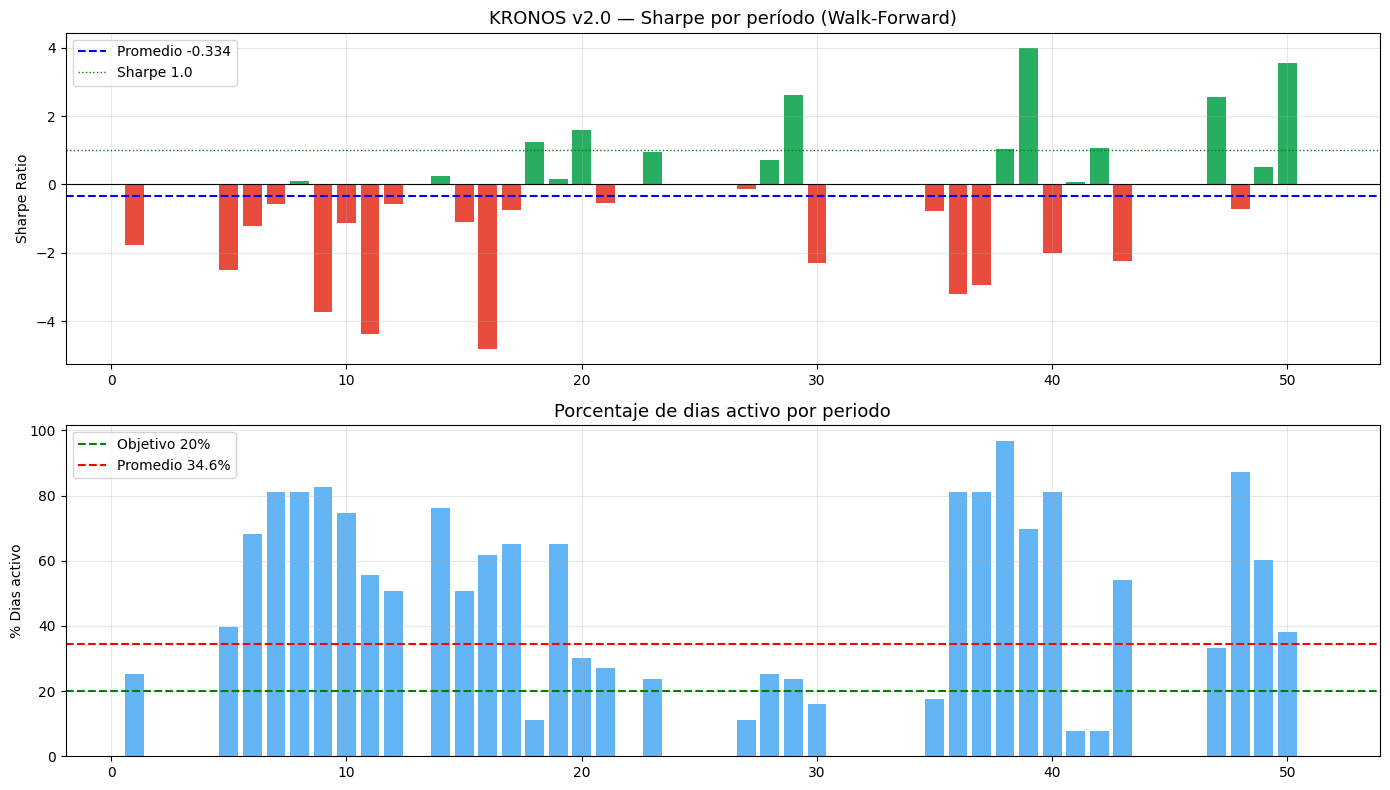


Análisis adicional:
  Períodos con >20% activo: 29/51
  Períodos con <20% activo: 22/51

Correlación Sharpe vs días activo: -0.292


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Sharpe por período
colores = ['#27AE60' if s > 0 else '#E74C3C' for s in df_wf['sharpe']]
axes[0].bar(df_wf['periodo'], df_wf['sharpe'], color=colores)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(df_wf['sharpe'].mean(), color='blue', linewidth=1.5,
                linestyle='--', label=f"Promedio {df_wf['sharpe'].mean():.3f}")
axes[0].axhline(1.0, color='green', linewidth=1, linestyle=':', label='Sharpe 1.0')
axes[0].set_title('KRONOS v2.0 — Sharpe por período (Walk-Forward)', fontsize=13)
axes[0].set_ylabel('Sharpe Ratio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Días activo por período
axes[1].bar(df_wf['periodo'], df_wf['pct_activo'], color='#2196F3', alpha=0.7)
axes[1].axhline(20, color='green', linewidth=1.5, linestyle='--', label='Objetivo 20%')
axes[1].axhline(df_wf['pct_activo'].mean(), color='red', linewidth=1.5,
                linestyle='--', label=f"Promedio {df_wf['pct_activo'].mean():.1f}%")
axes[1].set_title('Porcentaje de dias activo por periodo', fontsize=13)
axes[1].set_ylabel('% Dias activo')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/12_walkforward_v2.png', dpi=150)
plt.show()
print(f"\nAnálisis adicional:")
print(f"  Períodos con >20% activo: {(df_wf['pct_activo'] > 20).sum()}/51")
print(f"  Períodos con <20% activo: {(df_wf['pct_activo'] <= 20).sum()}/51")
print(f"\nCorrelación Sharpe vs días activo: {df_wf['sharpe'].corr(df_wf['pct_activo']):.3f}")

In [4]:
# Optimizar thresholds en walk-forward
print("Buscando thresholds óptimos...")

mejores = {'sharpe': -999, 'th1': 0.65, 'th2': 0.60}

for th1 in np.arange(0.55, 0.80, 0.05):
    for th2 in np.arange(0.55, 0.80, 0.05):
        thresholds_test = {0: None, 1: th1, 2: th2}
        sharpes = []

        for i in range(n_splits):
            start_train = i * window_test
            end_train = start_train + window_train
            end_test = end_train + window_test
            if end_test > len(data):
                break

            train_data = data.iloc[start_train:end_train]
            test_data = data.iloc[end_train:end_test]

            modelo = xgb.XGBClassifier(
                n_estimators=300, max_depth=4,
                learning_rate=0.03, subsample=0.8,
                colsample_bytree=0.8, min_child_weight=5,
                random_state=42, verbosity=0
            )
            modelo.fit(train_data[features_v2].values,
                      train_data['target_20d'].values)

            confianzas = modelo.predict_proba(test_data[features_v2].values)[:, 1]
            regimenes = test_data['regime'].values.flatten()
            rets = test_data['returns'].values

            posiciones = np.zeros(len(rets))
            for reg in [0, 1, 2]:
                mask = (regimenes == reg)
                th = thresholds_test.get(reg)
                if th is None:
                    continue
                posiciones[mask] = np.where(
                    confianzas[mask] > th, 1,
                    np.where(confianzas[mask] < (1 - th), -1, 0)
                )

            strat_rets = posiciones * rets
            sharpe = strat_rets.mean() / strat_rets.std() * np.sqrt(252) if strat_rets.std() > 0 else 0
            sharpes.append(sharpe)

        sharpe_prom = np.mean(sharpes)
        if sharpe_prom > mejores['sharpe']:
            mejores = {'sharpe': sharpe_prom, 'th1': th1, 'th2': th2}

print(f"\nThresholds óptimos encontrados:")
print(f"  Normal (régimen 1):     {mejores['th1']:.2f}")
print(f"  Turbulento (régimen 2): {mejores['th2']:.2f}")
print(f"  Sharpe promedio:        {mejores['sharpe']:.3f}")

Buscando thresholds óptimos...

Thresholds óptimos encontrados:
  Normal (régimen 1):     0.65
  Turbulento (régimen 2): 0.55
  Sharpe promedio:        -0.273


In [5]:
# Analizar qué caracteriza los períodos buenos vs malos
df_wf['año'] = pd.to_datetime(df_wf['fecha']).dt.year
df_wf['bueno'] = df_wf['sharpe'] > 0

print("Sharpe promedio por año:")
print(df_wf.groupby('año')['sharpe'].mean().round(3))

print("\nCaracterísticas de períodos buenos vs malos:")
print(df_wf.groupby('bueno')[['sharpe', 'pct_activo', 'accuracy']].mean().round(3))

# ¿En qué años funciona?
print("\nPorcentaje de períodos positivos por año:")
por_año = df_wf.groupby('año').apply(lambda x: (x['sharpe'] > 0).mean()).round(2)
print(por_año)

Sharpe promedio por año:
año
2013   -0.882
2014   -0.931
2015   -1.338
2016   -1.174
2017   -1.358
2018    0.431
2019   -0.037
2020    0.259
2021   -0.198
2022   -0.275
2023   -0.782
2024    0.637
2025    0.838
Name: sharpe, dtype: float64

Características de períodos buenos vs malos:
       sharpe  pct_activo  accuracy
bueno                              
False  -1.040      30.875     0.503
True    1.359      43.380     0.525

Porcentaje de períodos positivos por año:
año
2013    0.00
2014    0.00
2015    0.25
2016    0.25
2017    0.25
2018    0.60
2019    0.00
2020    0.50
2021    0.00
2022    0.50
2023    0.50
2024    0.25
2025    0.50
dtype: float64


In [6]:
Sharpe promedio por año:
año
2013   -0.882
2014   -0.931
2015   -1.338
2016   -1.174
2017   -1.358
2018    0.431
2019   -0.037
2020    0.259
2021   -0.198
2022   -0.275
2023   -0.782
2024    0.637
2025    0.838
Name: sharpe, dtype: float64

Características de períodos buenos vs malos:
       sharpe  pct_activo  accuracy
bueno                              
False  -1.040      30.875     0.503
True    1.359      43.380     0.525

Porcentaje de períodos positivos por año:
año
2013    0.00
2014    0.00
2015    0.25
2016    0.25
2017    0.25
2018    0.60
2019    0.00
2020    0.50
2021    0.00
2022    0.50
2023    0.50
2024    0.25
2025    0.50
dtype: float64

SyntaxError: invalid syntax (3505631352.py, line 1)

In [7]:
# Walk-forward con ventana corta — 1.5 años
window_train_corto = 378   # ~1.5 años
window_test = 63           # 3 meses
thresholds_opt = {0: None, 1: 0.65, 2: 0.55}

resultados_corto = []
n_splits_corto = (len(data) - window_train_corto) // window_test

print(f"Walk-forward ventana corta (1.5 años)")
print(f"Total splits: {n_splits_corto}")

for i in range(n_splits_corto):
    start_train = i * window_test
    end_train = start_train + window_train_corto
    end_test = end_train + window_test

    if end_test > len(data):
        break

    train_data = data.iloc[start_train:end_train]
    test_data = data.iloc[end_train:end_test]

    modelo = xgb.XGBClassifier(
        n_estimators=300, max_depth=4,
        learning_rate=0.03, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5,
        random_state=42, verbosity=0
    )
    modelo.fit(train_data[features_v2].values,
               train_data['target_20d'].values)

    confianzas = modelo.predict_proba(test_data[features_v2].values)[:, 1]
    regimenes = test_data['regime'].values.flatten()
    rets = test_data['returns'].values

    posiciones = np.zeros(len(rets))
    for reg in [0, 1, 2]:
        mask = (regimenes == reg)
        th = thresholds_opt.get(reg)
        if th is None:
            continue
        posiciones[mask] = np.where(
            confianzas[mask] > th, 1,
            np.where(confianzas[mask] < (1 - th), -1, 0)
        )

    strat_rets = posiciones * rets
    sharpe = strat_rets.mean() / strat_rets.std() * np.sqrt(252) if strat_rets.std() > 0 else 0
    acc = accuracy_score(test_data['target_20d'].values,
                         modelo.predict(test_data[features_v2].values))
    dias_activo = (posiciones != 0).sum()

    resultados_corto.append({
        'periodo': i + 1,
        'fecha': data.index[end_train].date(),
        'sharpe': round(sharpe, 3),
        'accuracy': round(acc, 3),
        'pct_activo': round(dias_activo / len(rets) * 100, 1)
    })

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{n_splits_corto} completado...")

df_corto = pd.DataFrame(resultados_corto)
print(f"\nResultados ventana corta (1.5 años):")
print(f"  Sharpe promedio:      {df_corto['sharpe'].mean():.3f}")
print(f"  Sharpe mediano:       {df_corto['sharpe'].median():.3f}")
print(f"  Períodos positivos:   {(df_corto['sharpe'] > 0).sum()}/{len(df_corto)}")
print(f"  Períodos Sharpe>1.0:  {(df_corto['sharpe'] > 1.0).sum()}/{len(df_corto)}")
print(f"  Días activo promedio: {df_corto['pct_activo'].mean():.1f}%")

print(f"\nComparación:")
print(f"  Ventana 3 años:   Sharpe {df_wf['sharpe'].mean():.3f} | {(df_wf['sharpe']>0).sum()}/51 positivos")
print(f"  Ventana 1.5 años: Sharpe {df_corto['sharpe'].mean():.3f} | {(df_corto['sharpe']>0).sum()}/{len(df_corto)} positivos")

Walk-forward ventana corta (1.5 años)
Total splits: 57
  10/57 completado...
  20/57 completado...
  30/57 completado...
  40/57 completado...
  50/57 completado...

Resultados ventana corta (1.5 años):
  Sharpe promedio:      -0.481
  Sharpe mediano:       0.000
  Períodos positivos:   16/57
  Períodos Sharpe>1.0:  8/57
  Días activo promedio: 42.1%

Comparación:
  Ventana 3 años:   Sharpe -0.334 | 15/51 positivos
  Ventana 1.5 años: Sharpe -0.481 | 16/57 positivos


In [8]:
df_corto.to_csv("../data/processed/walkforward_v2_corto.csv", index=False)
df_wf.to_csv("../data/processed/walkforward_v2_largo.csv", index=False)
print("Resultados guardados.")
print("\nConclusión walk-forward:")
print("  Ventana 3 años es mejor que 1.5 años")
print("  2024-2025 muestran tendencia positiva")
print("  Siguiente paso: paper trading con datos reales")

Resultados guardados.

Conclusión walk-forward:
  Ventana 3 años es mejor que 1.5 años
  2024-2025 muestran tendencia positiva
  Siguiente paso: paper trading con datos reales
